# Notebook 5: Qualitative comparison: DiffPure vs JPEG warm-start + DiffPure

This notebook **visualizes** how DiffPure behaves on a single adversarial example, and compares:
- **DiffPure-only** purification trajectory
- **JPEG (warm-start) + DiffPure** trajectory

**What we show**
- A *single* shared adversarial image (PGD $\ell_\infty$) used for both rows
- Intermediate snapshots along *one* reverse-SDE trajectory (no re-running DiffPure per snapshot)

In [3]:
# Install dependencies
# If you are on Colab and %pip causes issues, replace it with !pip

%pip install robustbench torchsde einops --quiet
%pip install -U pip wheel ninja --quiet
%pip install git+https://github.com/fra31/auto-attack
!python -m pip install --no-cache-dir "setuptools<81" --quiet

import os, sys

if not os.path.exists("DiffPure"):
    !git clone https://github.com/NVlabs/DiffPure.git

sys.path.insert(0, "DiffPure")
sys.path.insert(0, "DiffPure/score_sde")

  Cloning https://github.com/fra31/auto-attack to /tmp/pip-req-build-ub6_o14_
  Running command git clone --filter=blob:none --quiet https://github.com/fra31/auto-attack /tmp/pip-req-build-ub6_o14_
  Resolved https://github.com/fra31/auto-attack to commit a39220048b3c9f2cca9a4d3a54604793c68eca7e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


## Checkpoint path

Set `CKPT_PATH` to your CIFAR-10 score-SDE checkpoint.
If you are in Colab and the checkpoint is in Drive, you can mount Drive below.

In [4]:
# Optional Colab Drive mount
# Uncomment if needed

from google.colab import drive
drive.mount('/content/drive')

# UPDATE THIS PATH
CKPT_PATH = '/content/drive/MyDrive/checkpoint_8.pth'

assert os.path.exists(CKPT_PATH), f"Checkpoint not found: {CKPT_PATH}"
print("Using checkpoint:", CKPT_PATH)

Mounted at /content/drive
Using checkpoint: /content/drive/MyDrive/checkpoint_8.pth


In [5]:
import os
import io
import time
import math
import random
import argparse
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torchsde

from robustbench.data import load_cifar10
from robustbench.utils import load_model as rb_load_model

from score_sde.losses import get_optimizer
from score_sde.models import utils as mutils
from score_sde.models.ema import ExponentialMovingAverage
from score_sde import sde_lib
import score_sde.models.ncsnpp

In [6]:
# -----------------------------
# Config
# -----------------------------
SEED = 42
SAMPLE_INDEX = 0

JPEG_QUALITY = 75

# We only need one sample for visualization
N_SAMPLES = max(1, SAMPLE_INDEX + 1)

# PGD Linf attack settings
ATTACK_EPS = 8.0 / 255.0
ATTACK_ALPHA = 2.0 / 255.0
ATTACK_STEPS = 10

# DiffPure settings
SCORE_TYPE = "score_sde"
SAMPLE_STEP = 1
USE_BM = False

# Visualization times
DIFFPURE_TIMES = [0.075, 0.050, 0.025]   # shown before final purified output
JPEG_DIFFPURE_TIMES = [0.050, 0.025]

# Where to save outputs
OUT_DIR = Path("./visualization_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print("Device:", DEVICE)

def set_seed(seed=SEED):
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if hasattr(torch.backends, "cudnn"):
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

set_seed()

Device: cuda


## Load CIFAR-10 sample

In [7]:
x_test, y_test = load_cifar10(n_examples=N_SAMPLES, data_dir="./data")
x_test, y_test = x_test.to(DEVICE), y_test.to(DEVICE)

x_clean = x_test[SAMPLE_INDEX:SAMPLE_INDEX+1]
y_clean = y_test[SAMPLE_INDEX:SAMPLE_INDEX+1]

print("x_clean shape:", x_clean.shape)
print("y_clean:", y_clean.item())
print("value range:", float(x_clean.min()), float(x_clean.max()))

100%|██████████| 170M/170M [00:13<00:00, 12.5MB/s]


x_clean shape: torch.Size([1, 3, 32, 32])
y_clean: 3
value range: 0.05098039284348488 1.0


## Load the score-SDE model and the CIFAR-10 Linf classifier

In [8]:
def build_config(device):
    cfg = argparse.Namespace()
    cfg.data = argparse.Namespace()
    cfg.data.dataset = "CIFAR10"
    cfg.data.image_size = 32
    cfg.data.num_channels = 3
    cfg.data.centered = True

    cfg.model = argparse.Namespace()
    cfg.model.name = "ncsnpp"
    cfg.model.scale_by_sigma = False
    cfg.model.ema_rate = 0.9999
    cfg.model.normalization = "GroupNorm"
    cfg.model.nonlinearity = "swish"
    cfg.model.nf = 128
    cfg.model.ch_mult = (1, 2, 2, 2)
    cfg.model.num_res_blocks = 8
    cfg.model.attn_resolutions = (16,)
    cfg.model.resamp_with_conv = True
    cfg.model.conditional = True
    cfg.model.fir = False
    cfg.model.fir_kernel = [1, 3, 3, 1]
    cfg.model.skip_rescale = True
    cfg.model.resblock_type = "biggan"
    cfg.model.progressive = "none"
    cfg.model.progressive_input = "none"
    cfg.model.progressive_combine = "sum"
    cfg.model.attention_type = "ddpm"
    cfg.model.init_scale = 0.0
    cfg.model.fourier_scale = 16
    cfg.model.conv_size = 3
    cfg.model.sigma_min = 0.01
    cfg.model.sigma_max = 50
    cfg.model.num_scales = 1000
    cfg.model.beta_min = 0.1
    cfg.model.beta_max = 20.0
    cfg.model.dropout = 0.1
    cfg.model.embedding_type = "positional"

    cfg.optim = argparse.Namespace()
    cfg.optim.optimizer = "Adam"
    cfg.optim.lr = 2e-4
    cfg.optim.beta1 = 0.9
    cfg.optim.eps = 1e-8
    cfg.optim.weight_decay = 0.0
    cfg.optim.warmup = 5000
    cfg.optim.grad_clip = 1.0

    cfg.device = device
    cfg.seed = SEED
    return cfg


def restore_checkpoint(ckpt_path, state, device):
    loaded = torch.load(ckpt_path, map_location=device)
    state["optimizer"].load_state_dict(loaded["optimizer"])
    state["model"].load_state_dict(loaded["model"], strict=False)
    state["ema"].load_state_dict(loaded["ema"])
    state["step"] = loaded["step"]


def load_score_sde_model(ckpt_path, device):
    config = build_config(device)
    model = mutils.create_model(config)
    optimizer = get_optimizer(config, model.parameters())
    ema = ExponentialMovingAverage(model.parameters(), decay=config.model.ema_rate)
    state = dict(step=0, optimizer=optimizer, model=model, ema=ema)
    restore_checkpoint(ckpt_path, state, device)
    ema.copy_to(model.parameters())
    model.eval().to(device)
    print(f"Loaded score_sde model (step={state['step']})")
    return model


score_model = load_score_sde_model(CKPT_PATH, DEVICE)

classifier_inf = rb_load_model(
    model_name="Standard",
    dataset="cifar10",
    threat_model="Linf"
).eval().to(DEVICE)

print("Loaded score model and CIFAR-10 Linf classifier.")

Loaded score_sde model (step=400005)


Downloading...
From (original): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC
From (redirected): https://drive.google.com/uc?id=1t98aEuzeTL8P7Kpd5DIrCoCL21BNZUhC&confirm=t&uuid=1d8cff6f-2997-438c-8c6a-904de92ce9e4
To: /content/models/cifar10/Linf/Standard.pt
100%|██████████| 292M/292M [00:04<00:00, 62.6MB/s]

Loaded score model and CIFAR-10 Linf classifier.


In [9]:
class RevVPSDE(nn.Module):
    def __init__(self, model, score_type="score_sde",
                 beta_min=0.1, beta_max=20.0, N=1000, img_shape=(3, 32, 32)):
        super().__init__()
        self.model = model
        self.score_type = score_type
        self.img_shape = img_shape
        self.beta_0 = beta_min
        self.beta_1 = beta_max
        self.N = N
        self.discrete_betas = torch.linspace(beta_min / N, beta_max / N, N)
        self.alphas = 1.0 - self.discrete_betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)
        self.vpsde = sde_lib.VPSDE(beta_min=beta_min, beta_max=beta_max, N=N)
        self.noise_type = "diagonal"
        self.sde_type = "ito"

    def vpsde_fn(self, t, x):
        beta_t = self.beta_0 + t * (self.beta_1 - self.beta_0)
        return -0.5 * beta_t[:, None] * x, torch.sqrt(beta_t)

    def rvpsde_fn(self, t, x, return_type="drift"):
        drift, diffusion = self.vpsde_fn(t, x)
        if return_type == "drift":
            x_img = x.view(-1, *self.img_shape)
            score_fn = mutils.get_score_fn(
                self.vpsde, self.model, train=False, continuous=True
            )
            score = score_fn(x_img, t).view(x.shape[0], -1)
            return drift - diffusion[:, None] ** 2 * score
        return diffusion

    def f(self, t, x):
        return -self.rvpsde_fn(1 - t.expand(x.shape[0]), x, "drift")

    def g(self, t, x):
        d = self.rvpsde_fn(1 - t.expand(x.shape[0]), x, "diffusion")
        return d[:, None].expand(x.shape)


rev_vpsde = RevVPSDE(score_model, SCORE_TYPE).to(DEVICE)
alphas_cumprod = rev_vpsde.alphas_cumprod.to(DEVICE)

print("RevVPSDE ready.")

RevVPSDE ready.


## JPEG helper

In [10]:
def jpeg_compress_tensor(x, quality=75):
    """True JPEG compression. x in [0,1] -> [0,1]."""
    device = x.device
    out = []
    for img in x:
        arr = (img.detach().cpu().clamp(0, 1) * 255).byte().permute(1, 2, 0).numpy()
        buf = io.BytesIO()
        Image.fromarray(arr).save(buf, format="JPEG", quality=quality)
        buf.seek(0)
        out.append(TF.to_tensor(Image.open(buf).convert("RGB")).to(device))
    return torch.stack(out)

print("JPEG helper ready.")

JPEG helper ready.


## DiffPure helpers

We separate:
- **forward noising**: create the noisy state at a chosen time
- **reverse diffusion**: go from that noisy state back to `t=0`

In [11]:
def time_to_steps(t_float, N=1000):
    """Convert e.g. 0.075 -> 75 steps when N=1000."""
    return max(1, int(round(t_float * N)))


def forward_noise_from_t(x_in, alphas_cumprod, t_float, device):
    """Create the noisy image used as the starting point for reverse diffusion."""
    t_steps = time_to_steps(t_float, N=len(alphas_cumprod))
    x0 = (x_in * 2.0 - 1.0).to(device)
    e = torch.randn_like(x0)
    a = alphas_cumprod[t_steps - 1]
    x_noisy = x0 * a.sqrt() + e * (1.0 - a).sqrt()
    x_noisy_01 = ((x_noisy + 1.0) / 2.0).clamp(0.0, 1.0)
    return x_noisy, x_noisy_01, t_steps


def reverse_segment(x_state, rev_vpsde, tau_start, tau_end, device, bm=None):
    """Run one reverse-diffusion segment from tau_start to tau_end.

    Here tau = 1 - t, so larger tau means later in the reverse process.
    x_state is in the centered [-1, 1] space expected by the reverse SDE.
    """
    B, C, H, W = x_state.shape
    ts = torch.tensor([tau_start, tau_end], device=device)
    x_flat = x_state.view(B, -1)
    if bm is not None:
        xs = torchsde.sdeint_adjoint(rev_vpsde, x_flat, ts, method="euler", bm=bm)
    else:
        xs = torchsde.sdeint_adjoint(rev_vpsde, x_flat, ts, method="euler")
    return xs[-1].view(B, C, H, W)


def run_diffpure_trajectory(x_in, start_t, capture_ts, rev_vpsde, alphas_cumprod, device, use_bm=True):
    """Run the correct DiffPure pipeline once and capture intermediate snapshots.

    Important: this is ONE trajectory per row. We first noise the input once at
    start_t, then continue the reverse process and capture states at the requested
    times. We do not re-run DiffPure independently for each displayed t, and we do
    not re-noise the intermediate outputs.

    Args:
        x_in: input image in [0, 1] of shape (B, C, H, W)
        start_t: starting diffusion level, e.g. 0.075
        capture_ts: list like [0.075, 0.050, 0.025, 0.0]

    Returns:
        snapshots: dict mapping each capture t to the corresponding image in [0, 1]
    """
    capture_ts = list(capture_ts)
    capture_ts = sorted(capture_ts, reverse=True)
    assert abs(capture_ts[0] - start_t) < 1e-8, "capture_ts must start with start_t"

    x_noisy, x_noisy_01, t_steps = forward_noise_from_t(x_in, alphas_cumprod, start_t, device)
    snapshots = {start_t: x_noisy_01}

    # tau is the forward variable used by RevVPSDE integration.
    tau_start = 1.0 - start_t
    tau_final = 1.0 - 1e-5

    bm = None
    if use_bm:
        B, C, H, W = x_noisy.shape
        bm = torchsde.BrownianInterval(
            t0=tau_start, t1=tau_final, size=(B, C * H * W), device=device
        )

    current = x_noisy
    prev_tau = tau_start

    for t_next in capture_ts[1:]:
        next_tau = tau_final if t_next <= 0.0 else 1.0 - t_next
        current = reverse_segment(current, rev_vpsde, prev_tau, next_tau, device, bm=bm)
        snapshots[t_next] = ((current + 1.0) / 2.0).clamp(0.0, 1.0)
        prev_tau = next_tau

    return snapshots


## Simple PGD $\ell_\infty$ attack for visualization

In [12]:
def pgd_linf_attack(model, x, y, epsilon=8/255, alpha=2/255, steps=10):
    model.eval()

    x_adv = x.clone().detach()
    x_adv = x_adv + torch.empty_like(x_adv).uniform_(-epsilon, epsilon)
    x_adv = torch.clamp(x_adv, 0.0, 1.0)

    for _ in range(steps):
        x_adv.requires_grad_(True)
        logits = model(x_adv)
        loss = F.cross_entropy(logits, y)
        grad = torch.autograd.grad(loss, x_adv)[0]

        x_adv = x_adv.detach() + alpha * grad.sign()
        x_adv = torch.max(torch.min(x_adv, x + epsilon), x - epsilon)
        x_adv = torch.clamp(x_adv, 0.0, 1.0)

    return x_adv.detach()

print("PGD Linf attack ready.")

PGD Linf attack ready.


## Small utility functions for predictions, saving, and plotting

In [13]:
CIFAR10_CLASSES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

def predict_with_conf(model, x):
    model.eval()
    with torch.no_grad():
        logits = model(x)
        probs = torch.softmax(logits, dim=1)
        conf, pred = probs.max(dim=1)
    return int(pred.item()), float(conf.item())

def denorm_np(x):
    x = x.detach().cpu().clamp(0, 1)[0]
    return x.permute(1, 2, 0).numpy()

def save_tensor_image(x, path):
    arr = (denorm_np(x) * 255).astype(np.uint8)
    Image.fromarray(arr).save(path)

def make_title(title, model, x):
    pred, conf = predict_with_conf(model, x)
    return f"{title}\n{CIFAR10_CLASSES[pred]} ({conf*100:.1f}%)"

def make_clean_ref_title(y):
    """Clean reference uses the ground-truth label only, no confidence percentage."""
    label = int(y.detach().cpu().item())
    return f"Clean Ref\n{CIFAR10_CLASSES[label]}"

def plot_row(images, titles, figsize=(16, 3)):
    fig, axes = plt.subplots(1, len(images), figsize=figsize)
    if len(images) == 1:
        axes = [axes]
    for ax, img, title in zip(axes, images, titles):
        ax.imshow(denorm_np(img))
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

def plot_two_rows(row1_images, row1_titles, row2_images, row2_titles, figsize=(18, 6), save_path=None):
    cols = max(len(row1_images), len(row2_images))
    fig, axes = plt.subplots(2, cols, figsize=figsize)
    for r in range(2):
        for c in range(cols):
            axes[r, c].axis("off")

    for c, (img, title) in enumerate(zip(row1_images, row1_titles)):
        axes[0, c].imshow(denorm_np(img))
        axes[0, c].set_title(title, fontsize=10)
        axes[0, c].axis("off")

    for c, (img, title) in enumerate(zip(row2_images, row2_titles)):
        axes[1, c].imshow(denorm_np(img))
        axes[1, c].set_title(title, fontsize=10)
        axes[1, c].axis("off")

    axes[0, 0].set_ylabel("DiffPure", fontsize=12)
    axes[1, 0].set_ylabel("JPEG+DiffPure", fontsize=12)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=220, bbox_inches="tight")
    plt.show()

## Build the shared adversarial example

We generate **one** adversarial image under **PGD $\ell_\infty$** and use the **same** adversarial image for both rows.

In [14]:
set_seed(SEED)

x_adv = pgd_linf_attack(
    classifier_inf,
    x_clean,
    y_clean,
    epsilon=ATTACK_EPS,
    alpha=ATTACK_ALPHA,
    steps=ATTACK_STEPS
)

clean_pred, clean_conf = predict_with_conf(classifier_inf, x_clean)
adv_pred, adv_conf = predict_with_conf(classifier_inf, x_adv)

print("Clean prediction:", CIFAR10_CLASSES[clean_pred], f"({clean_conf*100:.1f}%)")
print("Adversarial prediction:", CIFAR10_CLASSES[adv_pred], f"({adv_conf*100:.1f}%)")

Clean prediction: cat (100.0%)
Adversarial prediction: bird (100.0%)


## DiffPure-only row

Correct pipeline:
- start from the adversarial image
- noise it once to `t=0.075`
- continue one reverse-diffusion trajectory
- capture snapshots at `t=0.075`, `t=0.050`, `t=0.025`, and final `t=0`

This row should **not** run independent DiffPure calls from the adversarial image for each t,
and it should **not** chain by re-noising the displayed outputs. It is one trajectory.


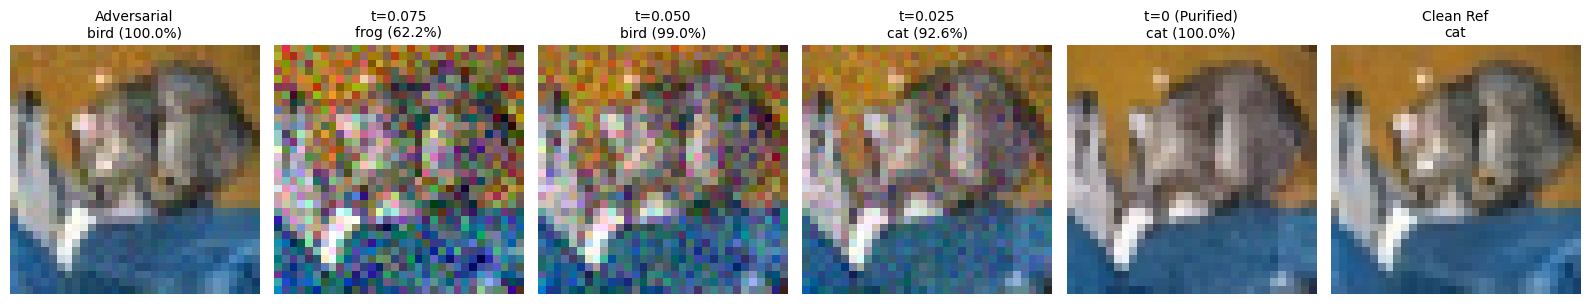

In [15]:
set_seed(SEED)

dp_capture_ts = [0.075, 0.050, 0.025, 0.0]
dp_snaps = run_diffpure_trajectory(
    x_adv,
    start_t=0.075,
    capture_ts=dp_capture_ts,
    rev_vpsde=rev_vpsde,
    alphas_cumprod=alphas_cumprod,
    device=DEVICE,
    use_bm=True,
)

dp_noisy_0075 = dp_snaps[0.075]
dp_noisy_0050 = dp_snaps[0.050]
dp_noisy_0025 = dp_snaps[0.025]
dp_final = dp_snaps[0.0]

dp_images = [
    x_adv,
    dp_noisy_0075,
    dp_noisy_0050,
    dp_noisy_0025,
    dp_final,
    x_clean,
]

dp_titles = [
    make_title("Adversarial", classifier_inf, x_adv),
    make_title("t=0.075", classifier_inf, dp_noisy_0075),
    make_title("t=0.050", classifier_inf, dp_noisy_0050),
    make_title("t=0.025", classifier_inf, dp_noisy_0025),
    make_title("t=0 (Purified)", classifier_inf, dp_final),
    make_clean_ref_title(y_clean),
]

plot_row(dp_images, dp_titles, figsize=(16, 3.2))


## JPEG-75 + DiffPure row

Correct pipeline:
- start from the same adversarial image
- apply JPEG-75 once
- noise the JPEG output once to `t=0.050`
- continue one reverse-diffusion trajectory
- capture snapshots at `t=0.050`, `t=0.025`, and final `t=0`


/usr/local/lib/python3.12/dist-packages/torchsde/_brownian/brownian_interval.py:599: UserWarning: Should have ta>=t0 but got ta=0.949999988079071 and t0=0.95.
  warnings.warn(f"Should have ta>=t0 but got ta={ta} and t0={self._start}.")


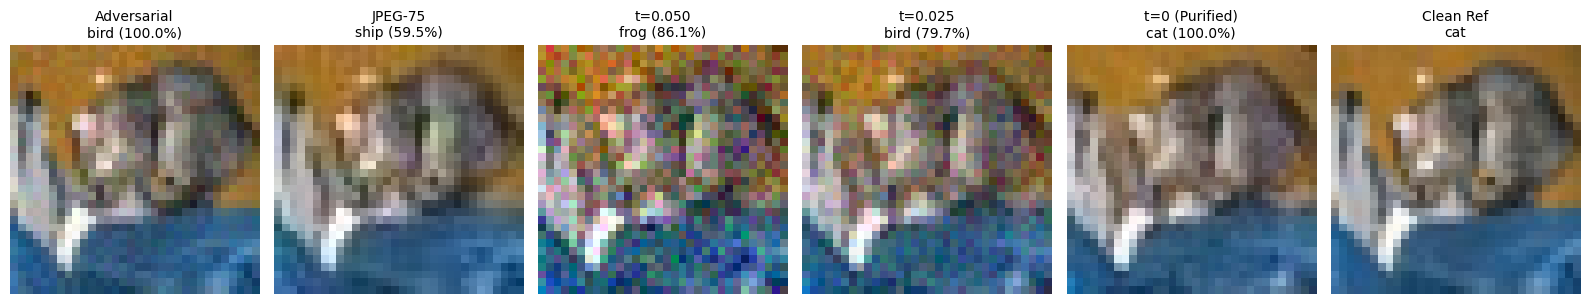

In [16]:
set_seed(SEED)

x_adv_jpeg = jpeg_compress_tensor(x_adv, quality=JPEG_QUALITY)

jdp_capture_ts = [0.050, 0.025, 0.0]
jdp_snaps = run_diffpure_trajectory(
    x_adv_jpeg,
    start_t=0.050,
    capture_ts=jdp_capture_ts,
    rev_vpsde=rev_vpsde,
    alphas_cumprod=alphas_cumprod,
    device=DEVICE,
    use_bm=True,
)

jdp_noisy_0050 = jdp_snaps[0.050]
jdp_noisy_0025 = jdp_snaps[0.025]
jdp_final = jdp_snaps[0.0]

jdp_images = [
    x_adv,
    x_adv_jpeg,
    jdp_noisy_0050,
    jdp_noisy_0025,
    jdp_final,
    x_clean,
]

jdp_titles = [
    make_title("Adversarial", classifier_inf, x_adv),
    make_title("JPEG-75", classifier_inf, x_adv_jpeg),
    make_title("t=0.050", classifier_inf, jdp_noisy_0050),
    make_title("t=0.025", classifier_inf, jdp_noisy_0025),
    make_title("t=0 (Purified)", classifier_inf, jdp_final),
    make_clean_ref_title(y_clean),
]

plot_row(jdp_images, jdp_titles, figsize=(16, 3.2))


## Combined figure and saved outputs

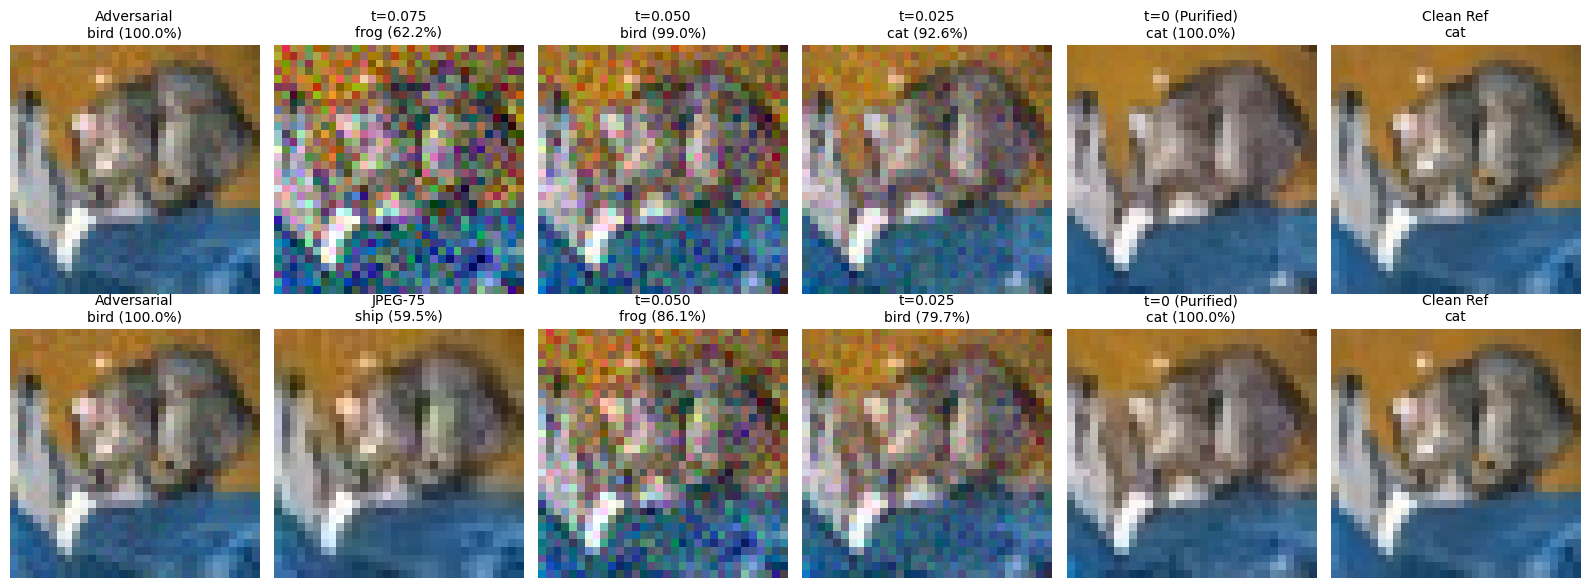

Saved combined figure to: visualization_outputs/diffpure_visualization_grid.png


In [17]:
combined_path = OUT_DIR / "diffpure_visualization_grid.png"

plot_two_rows(
    dp_images, dp_titles,
    jdp_images, jdp_titles,
    figsize=(16, 6),
    save_path=combined_path
)

print("Saved combined figure to:", combined_path)

In [18]:
# Save individual images too
save_map = {
    "clean_reference.png": x_clean,
    "adversarial.png": x_adv,

    "diffpure_t_0_075.png": dp_noisy_0075,
    "diffpure_t_0_050.png": dp_noisy_0050,
    "diffpure_t_0_025.png": dp_noisy_0025,
    "diffpure_t_0_purified.png": dp_final,

    "jpeg75.png": x_adv_jpeg,
    "jpeg_diffpure_t_0_050.png": jdp_noisy_0050,
    "jpeg_diffpure_t_0_025.png": jdp_noisy_0025,
    "jpeg_diffpure_t_0_purified.png": jdp_final,
}

for name, tensor in save_map.items():
    save_tensor_image(tensor, OUT_DIR / name)

print("Saved individual images to:", OUT_DIR.resolve())
for p in sorted(OUT_DIR.iterdir()):
    print(" -", p.name)


Saved individual images to: /content/visualization_outputs
 - adversarial.png
 - clean_reference.png
 - diffpure_t_0_025.png
 - diffpure_t_0_050.png
 - diffpure_t_0_075.png
 - diffpure_t_0_purified.png
 - diffpure_visualization_grid.png
 - jpeg75.png
 - jpeg_diffpure_t_0_025.png
 - jpeg_diffpure_t_0_050.png
 - jpeg_diffpure_t_0_purified.png
